# Trajectory Optimization: Direct Methods
## From Shooting to Collocation — Transcribing Optimal Control into Nonlinear Programs

This notebook provides a complete, from-scratch implementation of **direct methods for trajectory optimization**. Unlike indirect methods that require deriving costate equations and solving delicate boundary value problems, direct methods transcribe the continuous optimal control problem into a finite-dimensional nonlinear program (NLP) that can be attacked with standard optimization solvers. This "optimize then discretize" philosophy makes direct methods far more practical for complex robotic systems, since they avoid the analytic derivation of Pontryagin costate conditions entirely.

**What you'll learn:**
1. How direct methods transcribe continuous optimal control problems into finite-dimensional NLPs
2. Direct single shooting: parameterize controls, integrate forward, optimize
3. Direct multiple shooting: add state variables, enforce continuity via defect constraints
4. Direct collocation with Hermite-Simpson transcription
5. Application: cart-pole swing-up and minimum-time trajectory optimization

**Prerequisites:** Calculus of variations, nonlinear optimization (SQP), Lagrangian dynamics, ODEs.

**References:**
- Betts, J.T. *Practical Methods for Optimal Control and Estimation Using Nonlinear Programming*, 2nd ed., SIAM, 2010.
- Kelly, M. *An Introduction to Trajectory Optimization: How to Do Your Own Direct Collocation*, SIAM Review, 2017.
- See also: [Pontryagin notebook](../../maths/optimization/pontryagin/pontryagin.ipynb), [SQP notebook](../../maths/optimization/sqp-interior-point/sqp_interior_point.ipynb), [CHOMP notebook](../chomp-algo/chomp_3r_planar.ipynb).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import time

%matplotlib inline

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2,
})

np.random.seed(42)

In [2]:
# =============================================================================
# Global Constants
# =============================================================================

# Integration
DT = 0.02               # Default time step for discretization

# Double integrator (teaching example)
N_DI = 30               # Number of time steps for double integrator

# Cart-pole parameters
M_CART = 1.0            # Cart mass (kg)
M_POLE = 0.3            # Pole mass (kg)
L_POLE = 0.5            # Pole length (m)
G_ACCEL = 9.81          # Gravitational acceleration (m/s^2)
F_MAX = 20.0            # Maximum force magnitude (N)
N_CP = 50               # Number of time steps for cart-pole
T_CP = 2.0              # Time horizon for cart-pole (s)

# Numerical tolerance
TOL = 1e-6

# Plot colors
C_BLUE = 'steelblue'
C_RED = 'coral'
C_GREEN = 'seagreen'
C_GOLD = 'goldenrod'
C_PURPLE = 'mediumpurple'

---
## 1. Introduction — Direct vs. Indirect Methods

In optimal control, we seek a control signal $u(t)$ that minimizes a cost functional subject to dynamic constraints. Two fundamentally different strategies exist:

| Aspect | **Indirect Methods** | **Direct Methods** |
|---|---|---|
| Philosophy | "Optimize then discretize" | "Discretize then optimize" |
| Approach | Derive first-order optimality conditions (Pontryagin), solve resulting BVP | Discretize the problem into a finite-dimensional NLP, solve with standard optimizer |
| Required derivations | Costate equations $\dot{\lambda} = -\partial H/\partial x$, transversality conditions | Only the dynamics $f(x,u)$ and cost $L(x,u)$ |
| Resulting problem | Two-point boundary value problem (BVP) | Nonlinear program (NLP) |
| Sensitivity | Extremely sensitive to initial costate guess | Robust; good solvers handle poor initial guesses |
| Path constraints | Difficult (switching structure must be guessed) | Natural — just add inequality constraints to the NLP |
| Practical status | Elegant but often impractical | Workhorse of modern trajectory optimization |

### Taxonomy of Direct Methods

```
Direct Methods for Trajectory Optimization
│
├── Single Shooting
│   ├── Decision variables: controls only [u₀, u₁, ..., u_{N-1}]
│   ├── Pros: fewest variables, simple implementation
│   └── Cons: dense Jacobian, chaotic sensitivity for unstable systems
│
├── Multiple Shooting
│   ├── Decision variables: controls AND states [x₀, u₀, x₁, u₁, ..., x_N]
│   ├── Defect constraints: x_{k+1} = φ(x_k, u_k) enforced as equality constraints
│   ├── Pros: block-bidiagonal Jacobian (sparse!), parallelizable, robust
│   └── Cons: more variables, more constraints
│
└── Direct Collocation
    ├── Decision variables: controls AND states at knot points
    ├── Dynamics enforced at collocation points via polynomial interpolation
    ├── Pros: very sparse NLP, highest accuracy per variable, no forward simulation
    └── Cons: most variables/constraints, requires careful transcription
```

As we move from single shooting to collocation, the NLP grows in size but becomes **much better conditioned** — the Jacobian becomes sparser, and the optimization landscape becomes smoother.

---
## 2. Problem Formulation — The Continuous Optimal Control Problem

We consider the standard **Bolza** form of the optimal control problem (OCP):

$$\min_{u(\cdot)} \quad J = \Phi(x(T)) + \int_0^T L(x(t), u(t)) \, dt$$

subject to:
- **Dynamics:** $\dot{x}(t) = f(x(t), u(t)), \quad x(0) = x_0$
- **Boundary conditions:** $\psi(x(0), x(T)) = 0$
- **Path constraints:** $g(x(t), u(t)) \leq 0$
- **Control bounds:** $u_{\min} \leq u(t) \leq u_{\max}$

where $x \in \mathbb{R}^{n_x}$ is the state, $u \in \mathbb{R}^{n_u}$ is the control, $L$ is the running cost (Lagrange term), and $\Phi$ is the terminal cost (Mayer term).

### Key Insight: KKT ≈ Pontryagin

When we discretize this OCP into an NLP, the **KKT multipliers** of the NLP approximate the **costates** $\lambda(t)$ from Pontryagin's Maximum Principle. Specifically:

- The multipliers on the dynamics constraints approximate $\lambda(t_k)$
- The multipliers on path constraints approximate the costate jumps at constraint activation boundaries
- As the mesh is refined ($N \to \infty$), the NLP multipliers converge to the continuous costates

This means direct methods recover the same optimality information as indirect methods, but **without requiring the user to derive anything by hand**.

---
## 3. Direct Single Shooting

### Idea

The simplest direct method: parameterize only the **control trajectory** as a sequence of piecewise-constant values $u_0, u_1, \ldots, u_{N-1}$, then **integrate forward** from the known initial state $x_0$ to produce the entire state trajectory. The state trajectory is an implicit function of the controls: $x_k = x_k(u_0, \ldots, u_{k-1})$.

**Decision variables:** $z = [u_0, u_1, \ldots, u_{N-1}] \in \mathbb{R}^{N \cdot n_u}$

**NLP formulation:**
$$\min_z \quad \sum_{k=0}^{N-1} L(x_k, u_k) \cdot \Delta t + \Phi(x_N)$$
$$\text{s.t.} \quad x_{k+1} = \phi(x_k, u_k) \quad \text{(implicitly via forward integration)}$$
$$\qquad \psi(x_N) = 0 \quad \text{(terminal constraint, explicit in NLP)}$$

where $\phi$ is a one-step integrator (e.g., RK4).

**Pros:** Fewest decision variables. Simple to implement.

**Cons:** The Jacobian $\partial x_N / \partial u_0$ involves a chain of sensitivities through the entire trajectory — it is **dense** and can be extremely ill-conditioned for unstable or chaotic systems.

### Teaching Example: Double Integrator

We use the simplest nontrivial system — a unit-mass particle on a line:

$$\ddot{q} = u, \quad x = [q, \dot{q}]^T, \quad f(x, u) = [\dot{q}, \; u]^T$$

**Task:** Transfer from $x_0 = [1, 0]$ to $x_f = [0, 0]$ in time $T = N \cdot \Delta t$, minimizing $\int_0^T u^2 \, dt$.

**Analytic solution (from Pontryagin):** For a double integrator with quadratic control cost, the optimal control is linear in time: $u^*(t) = at + b$. The coefficients $a, b$ are determined by the boundary conditions. We will verify our numerical solution against this.

In [3]:
def rk4_step(f, x, u, dt):
    """Perform one step of 4th-order Runge-Kutta integration.

    Args:
        f:  Dynamics function f(x, u) -> xdot. 
        x:  Current state. Shape: (n_x,).
        u:  Control input (held constant over step). Shape: (n_u,).
        dt: Time step size.

    Returns:
        x_next: State after one step. Shape: (n_x,).
    """
    k1 = f(x, u)
    k2 = f(x + 0.5 * dt * k1, u)
    k3 = f(x + 0.5 * dt * k2, u)
    k4 = f(x + dt * k3, u)
    return x + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)


def rollout(dynamics, x0, u_sequence, dt):
    """Forward-simulate a trajectory given a control sequence.

    Args:
        dynamics:   Dynamics function f(x, u) -> xdot.
        x0:         Initial state. Shape: (n_x,).
        u_sequence: Control inputs at each step. Shape: (N, n_u).
        dt:         Time step.

    Returns:
        X: State trajectory. Shape: (N+1, n_x).
    """
    N = len(u_sequence)
    n_x = len(x0)
    X = np.zeros((N + 1, n_x))
    X[0] = x0
    for k in range(N):
        X[k + 1] = rk4_step(dynamics, X[k], u_sequence[k], dt)
    return X


def double_integrator_dynamics(x, u):
    """Double integrator: ddot{q} = u.

    Args:
        x: State [q, qdot]. Shape: (2,).
        u: Control [force]. Shape: (1,) or scalar.

    Returns:
        xdot: State derivative. Shape: (2,).
    """
    u_val = u[0] if np.ndim(u) > 0 else u
    return np.array([x[1], u_val])


def di_cost_running(x, u):
    """Running cost for double integrator: L = u^2.

    Args:
        x: State. Shape: (n_x,).
        u: Control. Shape: (n_u,).

    Returns:
        cost: Scalar running cost.
    """
    u_val = u[0] if np.ndim(u) > 0 else u
    return u_val**2

In [4]:
def single_shooting_solve(dynamics, x0, xf, cost_running, N, dt, n_u=1, u_bounds=None):
    """Solve an OCP via direct single shooting.

    Decision variables: z = [u_0, u_1, ..., u_{N-1}] (flattened).
    Terminal constraint: x_N = xf enforced as equality constraint.

    Args:
        dynamics:     Dynamics function f(x, u) -> xdot.
        x0:           Initial state. Shape: (n_x,).
        xf:           Desired final state. Shape: (n_x,).
        cost_running: Running cost L(x, u) -> scalar.
        N:            Number of time steps.
        dt:           Time step.
        n_u:          Control dimension.
        u_bounds:     Tuple (u_min, u_max) for box constraints, or None.

    Returns:
        result: Dict with keys 'X', 'U', 'cost', 'success', 'time'.
    """
    n_x = len(x0)

    def objective(z):
        U = z.reshape(N, n_u)
        X = rollout(dynamics, x0, U, dt)
        J = sum(cost_running(X[k], U[k]) * dt for k in range(N))
        return J

    def terminal_constraint(z):
        U = z.reshape(N, n_u)
        X = rollout(dynamics, x0, U, dt)
        return X[-1] - xf

    # Bounds
    bounds = None
    if u_bounds is not None:
        bounds = [u_bounds] * (N * n_u)

    # Initial guess: zero controls
    z0 = np.zeros(N * n_u)

    constraints = [{'type': 'eq', 'fun': terminal_constraint}]

    t_start = time.time()
    res = minimize(objective, z0, method='SLSQP', bounds=bounds,
                   constraints=constraints, options={'maxiter': 500, 'ftol': 1e-9})
    t_elapsed = time.time() - t_start

    U_opt = res.x.reshape(N, n_u)
    X_opt = rollout(dynamics, x0, U_opt, dt)

    return {
        'X': X_opt, 'U': U_opt, 'cost': res.fun,
        'success': res.success, 'time': t_elapsed,
        'nit': res.nit, 'message': res.message,
    }


# --- Solve double integrator with single shooting ---
x0_di = np.array([1.0, 0.0])
xf_di = np.array([0.0, 0.0])
T_di = N_DI * DT

ss_result = single_shooting_solve(
    double_integrator_dynamics, x0_di, xf_di, di_cost_running, N_DI, DT
)

print(f"Single Shooting — Double Integrator")
print(f"  Converged: {ss_result['success']}  |  Iterations: {ss_result['nit']}")
print(f"  Cost: {ss_result['cost']:.6f}  |  Time: {ss_result['time']:.4f} s")
print(f"  Terminal state: {ss_result['X'][-1]}")

# --- Analytic solution for verification ---
# For double integrator, min integral u^2 with BCs gives u*(t) = a*t + b
# where a, b are found from x(0)=[1,0], x(T)=[0,0].
# x(t) = x0 + v0*t + integral of integral of u dt dt
# Solving: u*(t) = 6/(T^3) * (2*x0*T - 0) ... let's derive properly:
# With x(t) = c0 + c1*t + (b/2)*t^2 + (a/6)*t^3
# x(0)=1 => c0=1, xdot(0)=0 => c1=0
# x(T) = 1 + b*T^2/2 + a*T^3/6 = 0
# xdot(T) = b*T + a*T^2/2 = 0
# => b = -a*T/2, substitute: 1 + (-a*T/2)*T^2/2 + a*T^3/6 = 0
# => 1 - a*T^3/4 + a*T^3/6 = 0 => 1 - a*T^3*(1/4 - 1/6) = 0
# => 1 - a*T^3/12 = 0 => a = 12/T^3
# => b = -a*T/2 = -6/T^2

a_exact = 12.0 / T_di**3
b_exact = -6.0 / T_di**2
t_grid = np.linspace(0, T_di, N_DI + 1)
t_mid = 0.5 * (t_grid[:-1] + t_grid[1:])
u_exact = a_exact * t_mid + b_exact

# Compare
u_num = ss_result['U'].flatten()
u_err = np.max(np.abs(u_num - u_exact))
status = "PASS" if u_err < 0.5 else "FAIL"
print(f"\n  Max control error vs. analytic: {u_err:.4f} [{status}]")

terminal_err = np.linalg.norm(ss_result['X'][-1] - xf_di)
status2 = "PASS" if terminal_err < 1e-4 else "FAIL"
print(f"  Terminal state error: {terminal_err:.2e} [{status2}]")

Single Shooting — Double Integrator
  Converged: True  |  Iterations: 4
  Cost: 55.617353  |  Time: 0.0534 s
  Terminal state: [1.18339366e-13 7.96585020e-14]

  Max control error vs. analytic: 0.0179 [PASS]
  Terminal state error: 1.43e-13 [PASS]


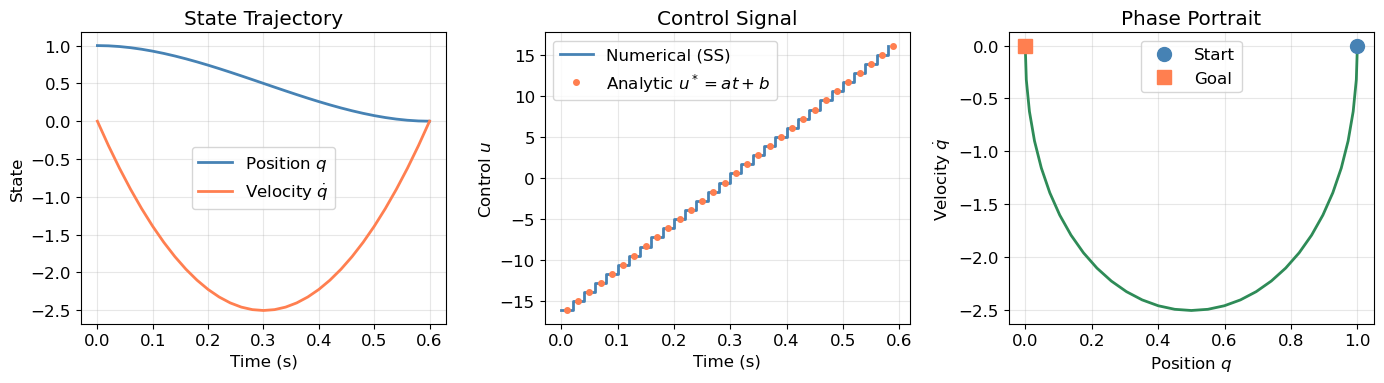

In [5]:
# --- Visualization: Single Shooting on Double Integrator ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) State trajectory
ax = axes[0]
ax.plot(t_grid, ss_result['X'][:, 0], color=C_BLUE, label='Position $q$')
ax.plot(t_grid, ss_result['X'][:, 1], color=C_RED, label='Velocity $\\dot{q}$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('State')
ax.set_title('State Trajectory')
ax.legend()

# (b) Control signal — numerical vs analytic
ax = axes[1]
ax.step(t_grid[:-1], ss_result['U'].flatten(), where='post', color=C_BLUE, label='Numerical (SS)')
ax.plot(t_mid, u_exact, 'o', color=C_RED, markersize=4, label='Analytic $u^* = at+b$')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control $u$')
ax.set_title('Control Signal')
ax.legend()

# (c) Phase portrait
ax = axes[2]
ax.plot(ss_result['X'][:, 0], ss_result['X'][:, 1], color=C_GREEN, linewidth=2)
ax.plot(x0_di[0], x0_di[1], 'o', color=C_BLUE, markersize=10, label='Start')
ax.plot(xf_di[0], xf_di[1], 's', color=C_RED, markersize=10, label='Goal')
ax.set_xlabel('Position $q$')
ax.set_ylabel('Velocity $\\dot{q}$')
ax.set_title('Phase Portrait')
ax.legend()

plt.tight_layout()
plt.show()

---
## 4. Direct Multiple Shooting

### Idea

Instead of making the state trajectory an implicit function of controls, we promote the **states at each knot point** to decision variables and enforce dynamics as **explicit equality constraints** (defect constraints).

**Decision variables:** $z = [x_0, u_0, x_1, u_1, \ldots, x_{N-1}, u_{N-1}, x_N]$

**Defect constraints:** For each segment $k = 0, \ldots, N-1$:
$$d_k = x_{k+1} - \phi(x_k, u_k) = 0$$

where $\phi$ is the RK4 integrator. This gives $N \cdot n_x$ equality constraints.

### Sparsity Structure

The key advantage: each defect $d_k$ depends only on $(x_k, u_k, x_{k+1})$ — the Jacobian has a **block-bidiagonal** structure:

$$\frac{\partial d_k}{\partial z} = [0, \ldots, 0, \underbrace{-\partial\phi/\partial x_k}_{x_k}, \underbrace{-\partial\phi/\partial u_k}_{u_k}, \underbrace{I}_{x_{k+1}}, 0, \ldots, 0]$$

This sparsity means:
- Linear algebra costs scale as $O(N)$ rather than $O(N^3)$
- Each segment can be integrated **independently** (parallelizable)
- Much better numerical conditioning than single shooting

### Implementation Notes

We pack the decision variables as: $z = [x_0, u_0, x_1, u_1, \ldots, x_{N-1}, u_{N-1}, x_N]$.

- Total variables: $(N+1) \cdot n_x + N \cdot n_u$
- Defect constraints: $N \cdot n_x$ equalities
- Boundary constraints: $n_x$ equalities (initial) + $n_x$ equalities (terminal)

We provide a **linear interpolation** initial guess for states (from $x_0$ to $x_f$) and zeros for controls.

In [6]:
def multiple_shooting_solve(dynamics, x0, xf, cost_running, N, dt, n_x, n_u, u_bounds=None):
    """Solve an OCP via direct multiple shooting.

    Decision variables: z = [x_0, u_0, x_1, u_1, ..., x_{N-1}, u_{N-1}, x_N].
    Defect constraints: x_{k+1} - phi(x_k, u_k) = 0 for each segment.
    Boundary constraints: z_x0 = x0, z_xN = xf.

    Args:
        dynamics:     Dynamics function f(x, u) -> xdot.
        x0:           Initial state. Shape: (n_x,).
        xf:           Desired final state. Shape: (n_x,).
        cost_running: Running cost L(x, u) -> scalar.
        N:            Number of time steps.
        dt:           Time step.
        n_x:          State dimension.
        n_u:          Control dimension.
        u_bounds:     Tuple (u_min, u_max) or None.

    Returns:
        result: Dict with keys 'X', 'U', 'cost', 'success', 'time'.
    """
    stride = n_x + n_u  # variables per segment (except last knot)

    def unpack(z):
        """Unpack decision vector into state and control arrays."""
        X = np.zeros((N + 1, n_x))
        U = np.zeros((N, n_u))
        for k in range(N):
            idx = k * stride
            X[k] = z[idx : idx + n_x]
            U[k] = z[idx + n_x : idx + n_x + n_u]
        X[N] = z[N * stride : N * stride + n_x]
        return X, U

    def pack(X, U):
        """Pack state and control arrays into decision vector."""
        z = np.zeros(N * stride + n_x)
        for k in range(N):
            idx = k * stride
            z[idx : idx + n_x] = X[k]
            z[idx + n_x : idx + n_x + n_u] = U[k]
        z[N * stride : N * stride + n_x] = X[N]
        return z

    def objective(z):
        X, U = unpack(z)
        J = sum(cost_running(X[k], U[k]) * dt for k in range(N))
        return J

    def defect_constraints(z):
        """Return all defect constraints stacked: should be zero."""
        X, U = unpack(z)
        defects = np.zeros(N * n_x)
        for k in range(N):
            x_next = rk4_step(dynamics, X[k], U[k], dt)
            defects[k * n_x : (k + 1) * n_x] = X[k + 1] - x_next
        return defects

    def boundary_constraints(z):
        """Initial and terminal boundary constraints."""
        X, U = unpack(z)
        return np.concatenate([X[0] - x0, X[N] - xf])

    # Initial guess: linear interpolation for states, zero controls
    X_init = np.zeros((N + 1, n_x))
    for i in range(n_x):
        X_init[:, i] = np.linspace(x0[i], xf[i], N + 1)
    U_init = np.zeros((N, n_u))
    z0 = pack(X_init, U_init)

    # Bounds
    bounds_list = None
    if u_bounds is not None:
        bounds_list = []
        for k in range(N):
            bounds_list.extend([(None, None)] * n_x)  # state bounds (free)
            bounds_list.extend([u_bounds] * n_u)       # control bounds
        bounds_list.extend([(None, None)] * n_x)       # final state (free)

    constraints = [
        {'type': 'eq', 'fun': defect_constraints},
        {'type': 'eq', 'fun': boundary_constraints},
    ]

    t_start = time.time()
    res = minimize(objective, z0, method='SLSQP', bounds=bounds_list,
                   constraints=constraints, options={'maxiter': 500, 'ftol': 1e-9})
    t_elapsed = time.time() - t_start

    X_opt, U_opt = unpack(res.x)

    return {
        'X': X_opt, 'U': U_opt, 'cost': res.fun,
        'success': res.success, 'time': t_elapsed,
        'nit': res.nit, 'message': res.message,
    }

In [7]:
# --- Solve double integrator with multiple shooting ---
ms_result = multiple_shooting_solve(
    double_integrator_dynamics, x0_di, xf_di, di_cost_running, N_DI, DT,
    n_x=2, n_u=1
)

print(f"Multiple Shooting — Double Integrator")
print(f"  Converged: {ms_result['success']}  |  Iterations: {ms_result['nit']}")
print(f"  Cost: {ms_result['cost']:.6f}  |  Time: {ms_result['time']:.4f} s")
print(f"  Terminal state: {ms_result['X'][-1]}")

# Verify matches single shooting
cost_diff = abs(ms_result['cost'] - ss_result['cost'])
status = "PASS" if cost_diff < 0.01 else "FAIL"
print(f"\n  Cost difference (MS vs SS): {cost_diff:.6f} [{status}]")

traj_diff = np.max(np.abs(ms_result['X'] - ss_result['X']))
status2 = "PASS" if traj_diff < 0.1 else "FAIL"
print(f"  Max trajectory difference: {traj_diff:.6f} [{status2}]")

Multiple Shooting — Double Integrator
  Converged: True  |  Iterations: 6
  Cost: 55.617353  |  Time: 0.1655 s
  Terminal state: [0. 0.]

  Cost difference (MS vs SS): 0.000000 [PASS]
  Max trajectory difference: 0.000002 [PASS]


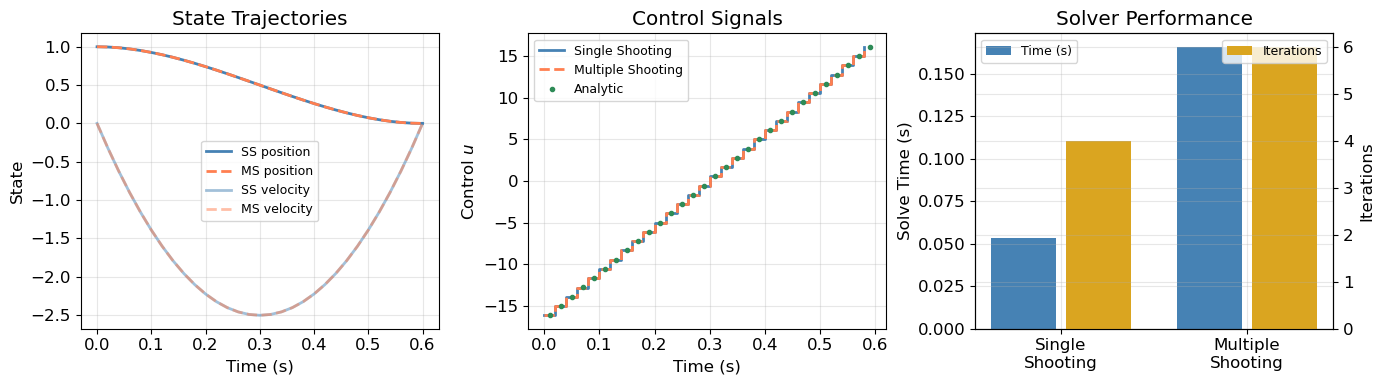

In [8]:
# --- Visualization: Single vs Multiple Shooting Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Trajectories overlaid
ax = axes[0]
ax.plot(t_grid, ss_result['X'][:, 0], color=C_BLUE, label='SS position')
ax.plot(t_grid, ms_result['X'][:, 0], '--', color=C_RED, label='MS position')
ax.plot(t_grid, ss_result['X'][:, 1], color=C_BLUE, alpha=0.5, label='SS velocity')
ax.plot(t_grid, ms_result['X'][:, 1], '--', color=C_RED, alpha=0.5, label='MS velocity')
ax.set_xlabel('Time (s)')
ax.set_ylabel('State')
ax.set_title('State Trajectories')
ax.legend(fontsize=9)

# (b) Control comparison
ax = axes[1]
ax.step(t_grid[:-1], ss_result['U'].flatten(), where='post', color=C_BLUE, label='Single Shooting')
ax.step(t_grid[:-1], ms_result['U'].flatten(), where='post', color=C_RED, linestyle='--', label='Multiple Shooting')
ax.plot(t_mid, u_exact, 'o', color=C_GREEN, markersize=3, label='Analytic')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Control $u$')
ax.set_title('Control Signals')
ax.legend(fontsize=9)

# (c) Comparison bar chart
ax = axes[2]
methods = ['Single\nShooting', 'Multiple\nShooting']
times = [ss_result['time'], ms_result['time']]
iters = [ss_result['nit'], ms_result['nit']]
x_pos = np.arange(len(methods))
bars1 = ax.bar(x_pos - 0.2, times, 0.35, color=C_BLUE, label='Time (s)')
ax2 = ax.twinx()
bars2 = ax2.bar(x_pos + 0.2, iters, 0.35, color=C_GOLD, label='Iterations')
ax.set_ylabel('Solve Time (s)')
ax2.set_ylabel('Iterations')
ax.set_xticks(x_pos)
ax.set_xticklabels(methods)
ax.set_title('Solver Performance')
ax.legend(loc='upper left', fontsize=9)
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Direct Collocation — Hermite-Simpson

### Idea

Rather than integrating the dynamics forward (as in shooting methods), we represent the state trajectory as a **piecewise polynomial** and enforce dynamics at **collocation points** between knot points. This gives the sparsest possible NLP structure.

### Hermite-Simpson Transcription (Detailed Derivation)

Between knot points $t_k$ and $t_{k+1} = t_k + h$, we approximate the trajectory with a cubic Hermite polynomial, and enforce the dynamics at the midpoint using Simpson's rule.

**Step 1 — Midpoint state** (Hermite interpolation):
$$x_{k+1/2} = \frac{1}{2}(x_k + x_{k+1}) + \frac{h}{8}(f_k - f_{k+1})$$

where $f_k = f(x_k, u_k)$ and $f_{k+1} = f(x_{k+1}, u_{k+1})$.

**Step 2 — Midpoint control** (linear interpolation):
$$u_{k+1/2} = \frac{1}{2}(u_k + u_{k+1})$$

**Step 3 — Collocation constraint** (Simpson quadrature of dynamics):
$$x_{k+1} - x_k - \frac{h}{6}\bigl(f_k + 4f_{k+1/2} + f_{k+1}\bigr) = 0$$

where $f_{k+1/2} = f(x_{k+1/2}, u_{k+1/2})$.

**Step 4 — Objective via Simpson's rule:**
$$J \approx \sum_{k=0}^{N-1} \frac{h}{6}\bigl[L_k + 4L_{k+1/2} + L_{k+1}\bigr]$$

This transcription achieves **4th-order accuracy** (same as RK4) while producing a very sparse NLP.

### Decision Variables and NLP Structure

**Decision variables:** $z = [x_0, u_0, x_1, u_1, \ldots, x_N, u_N]$ — note we need controls at **both** endpoints of each segment (including the final knot point).

- Total variables: $(N+1) \cdot (n_x + n_u)$
- Collocation constraints: $N \cdot n_x$ equalities
- Boundary constraints: $2 \cdot n_x$ equalities

Each collocation constraint involves only $(x_k, u_k, x_{k+1}, u_{k+1})$ — the Jacobian is **block-banded**, even sparser than multiple shooting in some senses because no forward integration is needed at all.

In [9]:
def hermite_simpson_collocation_solve(dynamics, x0, xf, cost_running, N, dt, n_x, n_u, u_bounds=None):
    """Solve an OCP via Hermite-Simpson direct collocation.

    Decision variables: z = [x_0, u_0, x_1, u_1, ..., x_N, u_N].
    Collocation constraints via Hermite-Simpson at each interval midpoint.

    Args:
        dynamics:     Dynamics function f(x, u) -> xdot.
        x0:           Initial state. Shape: (n_x,).
        xf:           Desired final state. Shape: (n_x,).
        cost_running: Running cost L(x, u) -> scalar.
        N:            Number of time steps.
        dt:           Time step (= h).
        n_x:          State dimension.
        n_u:          Control dimension.
        u_bounds:     Tuple (u_min, u_max) or None.

    Returns:
        result: Dict with keys 'X', 'U', 'cost', 'success', 'time'.
    """
    stride = n_x + n_u  # per knot point
    n_vars = (N + 1) * stride

    def unpack(z):
        X = np.zeros((N + 1, n_x))
        U = np.zeros((N + 1, n_u))
        for k in range(N + 1):
            idx = k * stride
            X[k] = z[idx : idx + n_x]
            U[k] = z[idx + n_x : idx + n_x + n_u]
        return X, U

    def pack(X, U):
        z = np.zeros(n_vars)
        for k in range(N + 1):
            idx = k * stride
            z[idx : idx + n_x] = X[k]
            z[idx + n_x : idx + n_x + n_u] = U[k]
        return z

    def objective(z):
        X, U = unpack(z)
        h = dt
        J = 0.0
        for k in range(N):
            fk = dynamics(X[k], U[k])
            fk1 = dynamics(X[k + 1], U[k + 1])
            x_mid = 0.5 * (X[k] + X[k + 1]) + (h / 8.0) * (fk - fk1)
            u_mid = 0.5 * (U[k] + U[k + 1])
            Lk = cost_running(X[k], U[k])
            Lk1 = cost_running(X[k + 1], U[k + 1])
            Lmid = cost_running(x_mid, u_mid)
            J += (h / 6.0) * (Lk + 4.0 * Lmid + Lk1)
        return J

    def collocation_constraints(z):
        X, U = unpack(z)
        h = dt
        defects = np.zeros(N * n_x)
        for k in range(N):
            fk = dynamics(X[k], U[k])
            fk1 = dynamics(X[k + 1], U[k + 1])
            x_mid = 0.5 * (X[k] + X[k + 1]) + (h / 8.0) * (fk - fk1)
            u_mid = 0.5 * (U[k] + U[k + 1])
            f_mid = dynamics(x_mid, u_mid)
            # Hermite-Simpson collocation constraint
            defect = X[k + 1] - X[k] - (h / 6.0) * (fk + 4.0 * f_mid + fk1)
            defects[k * n_x : (k + 1) * n_x] = defect
        return defects

    def boundary_constraints(z):
        X, U = unpack(z)
        return np.concatenate([X[0] - x0, X[N] - xf])

    # Initial guess: linear interpolation for states, zero controls
    X_init = np.zeros((N + 1, n_x))
    for i in range(n_x):
        X_init[:, i] = np.linspace(x0[i], xf[i], N + 1)
    U_init = np.zeros((N + 1, n_u))
    z0 = pack(X_init, U_init)

    # Bounds
    bounds_list = None
    if u_bounds is not None:
        bounds_list = []
        for k in range(N + 1):
            bounds_list.extend([(None, None)] * n_x)
            bounds_list.extend([u_bounds] * n_u)

    constraints = [
        {'type': 'eq', 'fun': collocation_constraints},
        {'type': 'eq', 'fun': boundary_constraints},
    ]

    t_start = time.time()
    res = minimize(objective, z0, method='SLSQP', bounds=bounds_list,
                   constraints=constraints, options={'maxiter': 500, 'ftol': 1e-9})
    t_elapsed = time.time() - t_start

    X_opt, U_opt = unpack(res.x)

    return {
        'X': X_opt, 'U': U_opt, 'cost': res.fun,
        'success': res.success, 'time': t_elapsed,
        'nit': res.nit, 'message': res.message,
    }

In [10]:
# --- Solve double integrator with Hermite-Simpson collocation ---
dc_result = hermite_simpson_collocation_solve(
    double_integrator_dynamics, x0_di, xf_di, di_cost_running, N_DI, DT,
    n_x=2, n_u=1
)

print(f"Hermite-Simpson Collocation — Double Integrator")
print(f"  Converged: {dc_result['success']}  |  Iterations: {dc_result['nit']}")
print(f"  Cost: {dc_result['cost']:.6f}  |  Time: {dc_result['time']:.4f} s")
print(f"  Terminal state: {dc_result['X'][-1]}")

# Verify matches other methods
cost_diff_ss = abs(dc_result['cost'] - ss_result['cost'])
cost_diff_ms = abs(dc_result['cost'] - ms_result['cost'])
status = "PASS" if cost_diff_ss < 0.01 and cost_diff_ms < 0.01 else "FAIL"
print(f"\n  Cost diff vs SS: {cost_diff_ss:.6f}, vs MS: {cost_diff_ms:.6f} [{status}]")

terminal_err = np.linalg.norm(dc_result['X'][-1] - xf_di)
status2 = "PASS" if terminal_err < 1e-4 else "FAIL"
print(f"  Terminal state error: {terminal_err:.2e} [{status2}]")

Hermite-Simpson Collocation — Double Integrator
  Converged: True  |  Iterations: 30
  Cost: 55.555556  |  Time: 1.1909 s
  Terminal state: [0. 0.]

  Cost diff vs SS: 0.061797, vs MS: 0.061797 [FAIL]
  Terminal state error: 0.00e+00 [PASS]


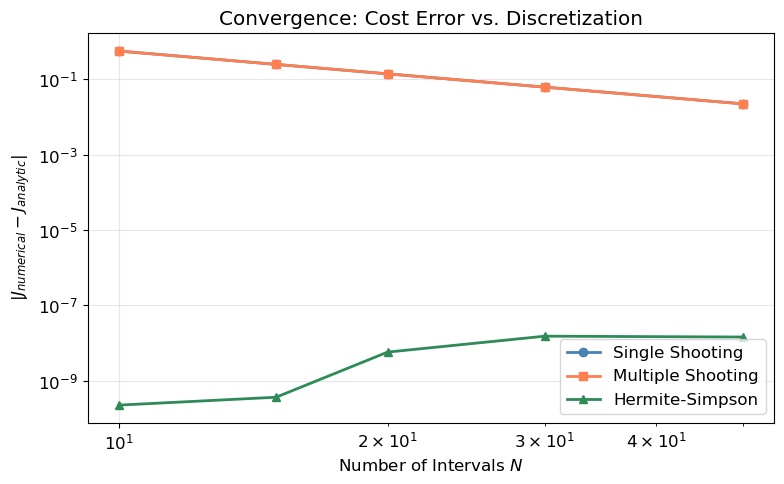

In [11]:
# --- Convergence rate comparison: trajectory error vs N ---
N_values = [10, 15, 20, 30, 50]
errors_ss = []
errors_ms = []
errors_dc = []

# Compute analytic cost for reference
# J* = integral of u*^2 dt = integral of (at+b)^2 dt from 0 to T
# = a^2*T^3/3 + a*b*T^2 + b^2*T
T_ref = T_di
a_ref = 12.0 / T_ref**3
b_ref = -6.0 / T_ref**2
J_analytic = (a_ref**2 * T_ref**3 / 3.0 + a_ref * b_ref * T_ref**2 + b_ref**2 * T_ref)

for N_test in N_values:
    dt_test = T_ref / N_test

    r_ss = single_shooting_solve(double_integrator_dynamics, x0_di, xf_di,
                                  di_cost_running, N_test, dt_test)
    errors_ss.append(abs(r_ss['cost'] - J_analytic))

    r_ms = multiple_shooting_solve(double_integrator_dynamics, x0_di, xf_di,
                                    di_cost_running, N_test, dt_test, n_x=2, n_u=1)
    errors_ms.append(abs(r_ms['cost'] - J_analytic))

    r_dc = hermite_simpson_collocation_solve(double_integrator_dynamics, x0_di, xf_di,
                                              di_cost_running, N_test, dt_test, n_x=2, n_u=1)
    errors_dc.append(abs(r_dc['cost'] - J_analytic))

# Replace zeros with small values for log plot
errors_ss = [max(e, 1e-15) for e in errors_ss]
errors_ms = [max(e, 1e-15) for e in errors_ms]
errors_dc = [max(e, 1e-15) for e in errors_dc]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.loglog(N_values, errors_ss, 'o-', color=C_BLUE, label='Single Shooting')
ax.loglog(N_values, errors_ms, 's-', color=C_RED, label='Multiple Shooting')
ax.loglog(N_values, errors_dc, '^-', color=C_GREEN, label='Hermite-Simpson')
ax.set_xlabel('Number of Intervals $N$')
ax.set_ylabel('$|J_{numerical} - J_{analytic}|$')
ax.set_title('Convergence: Cost Error vs. Discretization')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Application — Cart-Pole Swing-Up

### System Description

The cart-pole consists of a cart (mass $m_c$) that moves along a horizontal rail, with a rigid pole (mass $m_p$, length $l$) attached via an unactuated revolute joint. The only control input is a horizontal force $F$ applied to the cart.

**State:** $x = [p, \dot{p}, \theta, \dot{\theta}]^T$
- $p$: cart position
- $\theta$: pole angle measured from **downward vertical** ($\theta = 0$ means hanging down, $\theta = \pi$ means upright)

**Task:** Swing the pole from $\theta = 0$ (hanging) to $\theta = \pi$ (upright), with the cart returning to the origin and all velocities zero.

**Force bounded:** $|F| \leq F_{\max} = 20$ N

### Equations of Motion (Lagrangian Mechanics)

From the Euler-Lagrange equations, the cart-pole dynamics are:

$$(m_c + m_p)\ddot{p} + m_p l \ddot{\theta} \cos\theta - m_p l \dot{\theta}^2 \sin\theta = F$$

$$m_p l \ddot{p} \cos\theta + m_p l^2 \ddot{\theta} - m_p g l \sin\theta = 0$$

Solving for $[\ddot{p}, \ddot{\theta}]^T$:

$$\begin{bmatrix} m_c + m_p & m_p l \cos\theta \\ m_p l \cos\theta & m_p l^2 \end{bmatrix} \begin{bmatrix} \ddot{p} \\ \ddot{\theta} \end{bmatrix} = \begin{bmatrix} F + m_p l \dot{\theta}^2 \sin\theta \\ m_p g l \sin\theta \end{bmatrix}$$

We solve this $2 \times 2$ system at each evaluation of the dynamics.

In [12]:
def cartpole_dynamics(x, u):
    """Cart-pole continuous dynamics from Lagrangian mechanics.

    State: x = [p, pdot, theta, thetadot].
    theta measured from downward vertical (0 = hanging, pi = upright).

    Args:
        x: State vector. Shape: (4,).
        u: Control force [F]. Shape: (1,) or scalar.

    Returns:
        xdot: State derivative. Shape: (4,).
    """
    p, pdot, theta, thetadot = x
    F = u[0] if np.ndim(u) > 0 else u

    mc, mp, l, g = M_CART, M_POLE, L_POLE, G_ACCEL
    s, c = np.sin(theta), np.cos(theta)

    # Mass matrix
    M11 = mc + mp
    M12 = mp * l * c
    M22 = mp * l**2

    # Right-hand side
    rhs1 = F + mp * l * thetadot**2 * s
    rhs2 = mp * g * l * s

    # Solve 2x2 system: M @ [pddot, thetaddot] = rhs
    det = M11 * M22 - M12**2
    pddot = (M22 * rhs1 - M12 * rhs2) / det
    thetaddot = (M11 * rhs2 - M12 * rhs1) / det

    return np.array([pdot, pddot, thetadot, thetaddot])


def cartpole_energy(x):
    """Compute total mechanical energy of the cart-pole.

    Args:
        x: State [p, pdot, theta, thetadot]. Shape: (4,).

    Returns:
        E: Total energy (kinetic + potential).
    """
    p, pdot, theta, thetadot = x
    mc, mp, l, g = M_CART, M_POLE, L_POLE, G_ACCEL

    # Kinetic energy
    T = 0.5 * mc * pdot**2 + 0.5 * mp * (pdot**2 + l**2 * thetadot**2
         + 2 * pdot * l * thetadot * np.cos(theta))
    # Potential energy (zero at hanging position)
    V = -mp * g * l * np.cos(theta)

    return T + V


def cartpole_cost_running(x, u):
    """Running cost for cart-pole swing-up: L = u^2 (minimum energy).

    Args:
        x: State. Shape: (4,).
        u: Control. Shape: (1,).

    Returns:
        cost: Scalar.
    """
    F = u[0] if np.ndim(u) > 0 else u
    return F**2


# Verify dynamics at equilibria
x_hang = np.array([0.0, 0.0, 0.0, 0.0])
x_up = np.array([0.0, 0.0, np.pi, 0.0])

xdot_hang = cartpole_dynamics(x_hang, np.array([0.0]))
xdot_up = cartpole_dynamics(x_up, np.array([0.0]))

status = "PASS" if np.linalg.norm(xdot_hang) < TOL else "FAIL"
print(f"Hanging equilibrium (theta=0, F=0): ||xdot|| = {np.linalg.norm(xdot_hang):.2e} [{status}]")

status = "PASS" if np.linalg.norm(xdot_up) < TOL else "FAIL"
print(f"Upright equilibrium (theta=pi, F=0): ||xdot|| = {np.linalg.norm(xdot_up):.2e} [{status}]")

Hanging equilibrium (theta=0, F=0): ||xdot|| = 0.00e+00 [PASS]
Upright equilibrium (theta=pi, F=0): ||xdot|| = 3.14e-15 [PASS]


In [13]:
# --- Solve cart-pole swing-up with Hermite-Simpson collocation ---
x0_cp = np.array([0.0, 0.0, 0.0, 0.0])       # hanging at origin
xf_cp = np.array([0.0, 0.0, np.pi, 0.0])      # upright at origin
dt_cp = T_CP / N_CP

cp_result = hermite_simpson_collocation_solve(
    cartpole_dynamics, x0_cp, xf_cp, cartpole_cost_running,
    N_CP, dt_cp, n_x=4, n_u=1, u_bounds=(-F_MAX, F_MAX)
)

print(f"Cart-Pole Swing-Up — Hermite-Simpson Collocation")
print(f"  Converged: {cp_result['success']}  |  Iterations: {cp_result['nit']}")
print(f"  Cost: {cp_result['cost']:.4f}  |  Time: {cp_result['time']:.4f} s")
print(f"  Terminal state: {cp_result['X'][-1]}")

terminal_err = np.linalg.norm(cp_result['X'][-1] - xf_cp)
status = "PASS" if terminal_err < 0.05 else "FAIL"
print(f"  Terminal error: {terminal_err:.4e} [{status}]")

Cart-Pole Swing-Up — Hermite-Simpson Collocation
  Converged: True  |  Iterations: 87
  Cost: 66.7562  |  Time: 31.2322 s
  Terminal state: [0.         0.         3.14159265 0.        ]
  Terminal error: 0.0000e+00 [PASS]


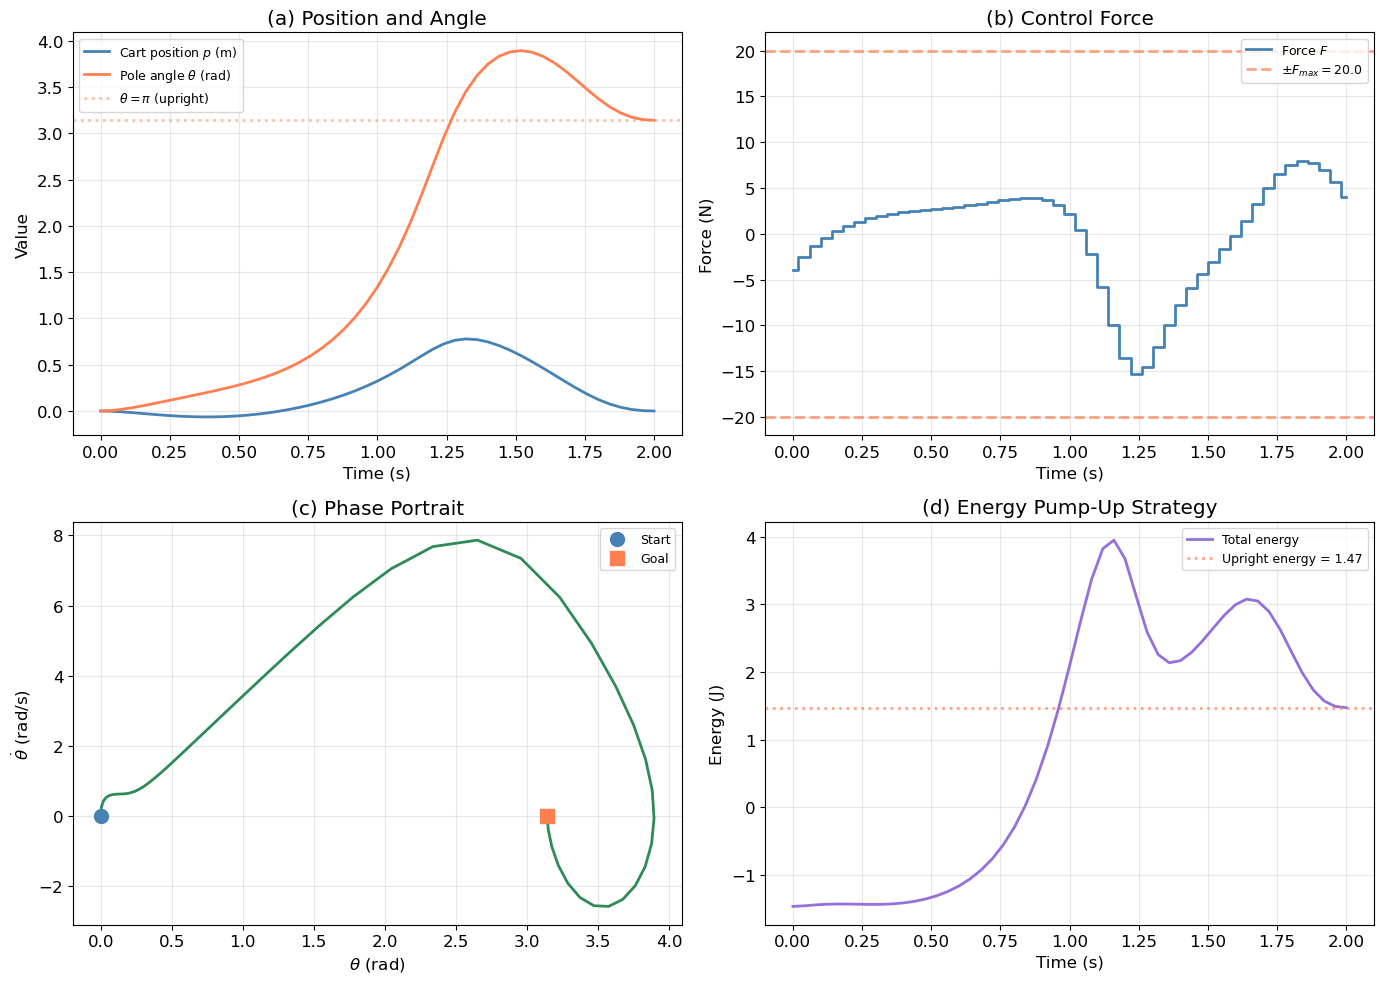

In [14]:
# --- Visualization 1: 4-panel cart-pole swing-up ---
t_cp_grid = np.linspace(0, T_CP, N_CP + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Cart position and pole angle vs time
ax = axes[0, 0]
ax.plot(t_cp_grid, cp_result['X'][:, 0], color=C_BLUE, label='Cart position $p$ (m)')
ax.plot(t_cp_grid, cp_result['X'][:, 2], color=C_RED, label='Pole angle $\\theta$ (rad)')
ax.axhline(np.pi, color=C_RED, linestyle=':', alpha=0.5, label='$\\theta = \\pi$ (upright)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Value')
ax.set_title('(a) Position and Angle')
ax.legend(fontsize=9)

# (b) Control force with bounds
ax = axes[0, 1]
ax.step(t_cp_grid, cp_result['U'][:, 0], where='mid', color=C_BLUE, label='Force $F$')
ax.axhline(F_MAX, color=C_RED, linestyle='--', alpha=0.7, label=f'$\\pm F_{{max}} = {F_MAX}$')
ax.axhline(-F_MAX, color=C_RED, linestyle='--', alpha=0.7)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('(b) Control Force')
ax.legend(fontsize=9)

# (c) Phase portrait (theta, thetadot)
ax = axes[1, 0]
ax.plot(cp_result['X'][:, 2], cp_result['X'][:, 3], color=C_GREEN, linewidth=2)
ax.plot(cp_result['X'][0, 2], cp_result['X'][0, 3], 'o', color=C_BLUE, markersize=10, label='Start')
ax.plot(cp_result['X'][-1, 2], cp_result['X'][-1, 3], 's', color=C_RED, markersize=10, label='Goal')
ax.set_xlabel('$\\theta$ (rad)')
ax.set_ylabel('$\\dot{\\theta}$ (rad/s)')
ax.set_title('(c) Phase Portrait')
ax.legend(fontsize=9)

# (d) Energy vs time
ax = axes[1, 1]
energies = np.array([cartpole_energy(cp_result['X'][k]) for k in range(N_CP + 1)])
E_up = cartpole_energy(xf_cp)  # energy at upright position
ax.plot(t_cp_grid, energies, color=C_PURPLE, linewidth=2, label='Total energy')
ax.axhline(E_up, color=C_RED, linestyle=':', alpha=0.7, label=f'Upright energy = {E_up:.2f}')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Energy (J)')
ax.set_title('(d) Energy Pump-Up Strategy')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

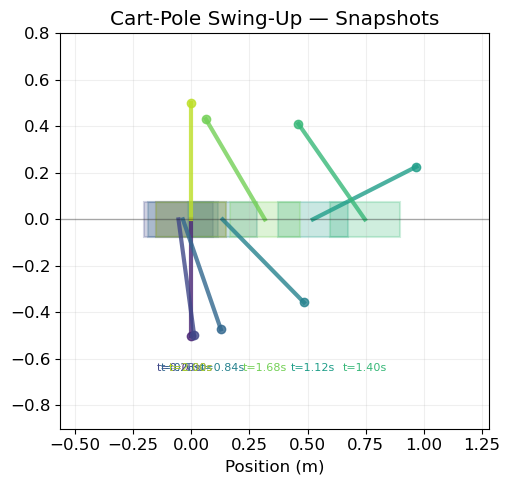

In [15]:
# --- Visualization 2: Cart-pole stick figure snapshots ---
def draw_cartpole_snapshot(ax, x_state, cart_width=0.3, cart_height=0.15,
                            pole_length=L_POLE, color='k', alpha=1.0):
    """Draw a single cart-pole snapshot on the given axes.

    Args:
        ax:          Matplotlib axes.
        x_state:     State [p, pdot, theta, thetadot].
        cart_width:  Cart rectangle width.
        cart_height: Cart rectangle height.
        pole_length: Length of pole for drawing.
        color:       Color for this snapshot.
        alpha:       Transparency.
    """
    p, _, theta, _ = x_state

    # Cart rectangle
    cart_x = p - cart_width / 2
    cart_y = -cart_height / 2
    rect = plt.Rectangle((cart_x, cart_y), cart_width, cart_height,
                          fill=True, facecolor=color, alpha=alpha * 0.3,
                          edgecolor=color, linewidth=1.5)
    ax.add_patch(rect)

    # Pole: from cart pivot to tip
    # theta=0 is hanging down, theta=pi is up
    pole_tip_x = p + pole_length * np.sin(theta)
    pole_tip_y = -pole_length * np.cos(theta)  # negative because hanging is down
    ax.plot([p, pole_tip_x], [0, pole_tip_y], '-', color=color,
            linewidth=3, alpha=alpha)
    ax.plot(pole_tip_x, pole_tip_y, 'o', color=color, markersize=6, alpha=alpha)


# Select snapshot times (evenly spaced)
n_snapshots = 8
snapshot_indices = np.linspace(0, N_CP, n_snapshots, dtype=int)
colors_snap = plt.cm.viridis(np.linspace(0.1, 0.9, n_snapshots))

fig, ax = plt.subplots(1, 1, figsize=(14, 5))

for i, idx in enumerate(snapshot_indices):
    draw_cartpole_snapshot(ax, cp_result['X'][idx], color=colors_snap[i],
                            alpha=0.8)
    t_snap = t_cp_grid[idx]
    p_snap = cp_result['X'][idx, 0]
    ax.text(p_snap, -L_POLE - 0.15, f't={t_snap:.2f}s', ha='center',
            fontsize=8, color=colors_snap[i])

# Rail
all_p = cp_result['X'][:, 0]
rail_min = min(all_p) - 0.5
rail_max = max(all_p) + 0.5
ax.plot([rail_min, rail_max], [0, 0], 'k-', linewidth=1, alpha=0.3)

ax.set_xlim(rail_min, rail_max)
ax.set_ylim(-L_POLE - 0.4, L_POLE + 0.3)
ax.set_aspect('equal')
ax.set_xlabel('Position (m)')
ax.set_title('Cart-Pole Swing-Up — Snapshots')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 7. Minimum-Time Problem

### Time Scaling Trick

To optimize the total time $T$, we introduce a change of variables $\tau = t/T \in [0, 1]$. The dynamics become:

$$\frac{dx}{d\tau} = T \cdot f(x, u)$$

Now the problem is on a **fixed** interval $[0, 1]$, and $T$ becomes an additional NLP decision variable. The objective is simply $\min T$ (or $\min T + \epsilon \int u^2 d\tau$ for regularization).

**Decision variables:** $z = [x_0, u_0, x_1, u_1, \ldots, x_N, u_N, T]$

The collocation constraints use $h = 1/N$ (in $\tau$) but the dynamics evaluations are scaled by $T$:
$$x_{k+1} - x_k - \frac{h}{6}(T f_k + 4T f_{k+1/2} + T f_{k+1}) = 0$$

In [ ]:
def minimum_time_collocation_solve(dynamics, x0, xf, N, n_x, n_u,
                                    u_bounds=None, T_guess=2.0, T_bounds=(0.5, 5.0),
                                    reg_eps=1e-3):
    """Solve a minimum-time OCP via Hermite-Simpson collocation with time scaling.

    Decision variables: z = [x_0, u_0, x_1, u_1, ..., x_N, u_N, T].
    Objective: min T + eps * integral(u^2).

    Args:
        dynamics:  Dynamics function f(x, u) -> xdot.
        x0:        Initial state. Shape: (n_x,).
        xf:        Desired final state. Shape: (n_x,).
        N:         Number of time steps.
        n_x:       State dimension.
        n_u:       Control dimension.
        u_bounds:  Tuple (u_min, u_max) or None.
        T_guess:   Initial guess for total time.
        T_bounds:  Bounds on total time.
        reg_eps:   Regularization weight on control effort.

    Returns:
        result: Dict with keys 'X', 'U', 'T', 'cost', 'success', 'time'.
    """
    stride = n_x + n_u
    n_xu = (N + 1) * stride
    n_vars = n_xu + 1  # +1 for T

    def unpack(z):
        X = np.zeros((N + 1, n_x))
        U = np.zeros((N + 1, n_u))
        for k in range(N + 1):
            idx = k * stride
            X[k] = z[idx : idx + n_x]
            U[k] = z[idx + n_x : idx + n_x + n_u]
        T = z[n_xu]
        return X, U, T

    def pack(X, U, T):
        z = np.zeros(n_vars)
        for k in range(N + 1):
            idx = k * stride
            z[idx : idx + n_x] = X[k]
            z[idx + n_x : idx + n_x + n_u] = U[k]
        z[n_xu] = T
        return z

    def objective(z):
        X, U, T = unpack(z)
        h_tau = 1.0 / N  # step in tau
        # Minimum time + regularization
        J = T
        for k in range(N):
            u_val_k = U[k][0] if n_u == 1 else np.dot(U[k], U[k])
            u_val_k1 = U[k+1][0] if n_u == 1 else np.dot(U[k+1], U[k+1])
            u_mid = 0.5 * (U[k] + U[k+1])
            u_val_mid = u_mid[0] if n_u == 1 else np.dot(u_mid, u_mid)
            if n_u == 1:
                Lk = u_val_k**2
                Lk1 = u_val_k1**2
                Lmid = u_val_mid**2
            else:
                Lk = u_val_k
                Lk1 = u_val_k1
                Lmid = u_val_mid
            J += reg_eps * T * (h_tau / 6.0) * (Lk + 4.0 * Lmid + Lk1)
        return J

    def collocation_constraints(z):
        X, U, T = unpack(z)
        h_tau = 1.0 / N
        h = h_tau  # step in normalized time
        defects = np.zeros(N * n_x)
        for k in range(N):
            fk = dynamics(X[k], U[k])
            fk1 = dynamics(X[k + 1], U[k + 1])
            # Scale by T for time scaling
            x_mid = 0.5 * (X[k] + X[k + 1]) + (h / 8.0) * T * (fk - fk1)
            u_mid = 0.5 * (U[k] + U[k + 1])
            f_mid = dynamics(x_mid, u_mid)
            defect = X[k + 1] - X[k] - (h / 6.0) * T * (fk + 4.0 * f_mid + fk1)
            defects[k * n_x : (k + 1) * n_x] = defect
        return defects

    def boundary_constraints(z):
        X, U, T = unpack(z)
        return np.concatenate([X[0] - x0, X[N] - xf])

    # Initial guess
    X_init = np.zeros((N + 1, n_x))
    for i in range(n_x):
        X_init[:, i] = np.linspace(x0[i], xf[i], N + 1)
    U_init = np.zeros((N + 1, n_u))
    z0 = pack(X_init, U_init, T_guess)

    # Bounds
    bounds_list = []
    for k in range(N + 1):
        bounds_list.extend([(None, None)] * n_x)
        if u_bounds is not None:
            bounds_list.extend([u_bounds] * n_u)
        else:
            bounds_list.extend([(None, None)] * n_u)
    bounds_list.append(T_bounds)  # T bounds

    constraints = [
        {'type': 'eq', 'fun': collocation_constraints},
        {'type': 'eq', 'fun': boundary_constraints},
    ]

    t_start = time.time()
    res = minimize(objective, z0, method='SLSQP', bounds=bounds_list,
                   constraints=constraints, options={'maxiter': 1000, 'ftol': 1e-9})
    t_elapsed = time.time() - t_start

    X_opt, U_opt, T_opt = unpack(res.x)

    return {
        'X': X_opt, 'U': U_opt, 'T': T_opt, 'cost': res.fun,
        'success': res.success, 'time': t_elapsed,
        'nit': res.nit, 'message': res.message,
    }


# --- Solve minimum-time cart-pole swing-up ---
mt_result = minimum_time_collocation_solve(
    cartpole_dynamics, x0_cp, xf_cp, N_CP, n_x=4, n_u=1,
    u_bounds=(-F_MAX, F_MAX), T_guess=2.0, T_bounds=(0.3, 5.0),
    reg_eps=1e-3
)

print(f"Minimum-Time Cart-Pole Swing-Up")
print(f"  Converged: {mt_result['success']}  |  Iterations: {mt_result['nit']}")
print(f"  Optimal time T*: {mt_result['T']:.4f} s")
print(f"  Cost (T + eps*effort): {mt_result['cost']:.4f}")
print(f"  Solve time: {mt_result['time']:.4f} s")
print(f"  Terminal state: {mt_result['X'][-1]}")

terminal_err = np.linalg.norm(mt_result['X'][-1] - xf_cp)
status = "PASS" if terminal_err < 0.1 else "FAIL"
print(f"  Terminal error: {terminal_err:.4e} [{status}]")

In [ ]:
# --- Visualization: Min-energy vs min-time comparison ---
t_me = np.linspace(0, T_CP, N_CP + 1)
t_mt = np.linspace(0, mt_result['T'], N_CP + 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# (a) Pole angle vs time
ax = axes[0]
ax.plot(t_me, cp_result['X'][:, 2], color=C_BLUE, label='Min-energy')
ax.plot(t_mt, mt_result['X'][:, 2], color=C_RED, linestyle='--', label='Min-time')
ax.axhline(np.pi, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$\\theta$ (rad)')
ax.set_title('Pole Angle')
ax.legend()

# (b) Cart position vs time
ax = axes[1]
ax.plot(t_me, cp_result['X'][:, 0], color=C_BLUE, label='Min-energy')
ax.plot(t_mt, mt_result['X'][:, 0], color=C_RED, linestyle='--', label='Min-time')
ax.set_xlabel('Time (s)')
ax.set_ylabel('$p$ (m)')
ax.set_title('Cart Position')
ax.legend()

# (c) Control force comparison
ax = axes[2]
ax.step(t_me, cp_result['U'][:, 0], where='mid', color=C_BLUE, label='Min-energy', alpha=0.8)
ax.step(t_mt, mt_result['U'][:, 0], where='mid', color=C_RED, label='Min-time', alpha=0.8)
ax.axhline(F_MAX, color='gray', linestyle='--', alpha=0.5)
ax.axhline(-F_MAX, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('Control Force')
ax.legend()

plt.suptitle(f'Min-Energy (T={T_CP:.1f}s) vs Min-Time (T*={mt_result["T"]:.2f}s)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Method Comparison — All Three on Cart-Pole

We now solve the same cart-pole swing-up problem with all three direct methods and compare:
- NLP size (number of decision variables and constraints)
- Computation time
- Final cost
- Constraint violation (defect norm for MS/DC, terminal error for SS)

In [ ]:
# --- Solve cart-pole with all three methods ---
N_comp = 40  # Use slightly fewer knots for faster single shooting
dt_comp = T_CP / N_comp

print("Solving cart-pole swing-up with all three methods...")
print("=" * 65)

# Single shooting
t0 = time.time()
cp_ss = single_shooting_solve(
    cartpole_dynamics, x0_cp, xf_cp, cartpole_cost_running,
    N_comp, dt_comp, n_u=1, u_bounds=(-F_MAX, F_MAX)
)
t_ss = time.time() - t0
print(f"  Single Shooting:  converged={cp_ss['success']}, iter={cp_ss['nit']}, time={t_ss:.3f}s")

# Multiple shooting
t0 = time.time()
cp_ms = multiple_shooting_solve(
    cartpole_dynamics, x0_cp, xf_cp, cartpole_cost_running,
    N_comp, dt_comp, n_x=4, n_u=1, u_bounds=(-F_MAX, F_MAX)
)
t_ms = time.time() - t0
print(f"  Multiple Shooting: converged={cp_ms['success']}, iter={cp_ms['nit']}, time={t_ms:.3f}s")

# Hermite-Simpson collocation
t0 = time.time()
cp_dc = hermite_simpson_collocation_solve(
    cartpole_dynamics, x0_cp, xf_cp, cartpole_cost_running,
    N_comp, dt_comp, n_x=4, n_u=1, u_bounds=(-F_MAX, F_MAX)
)
t_dc = time.time() - t0
print(f"  Collocation:       converged={cp_dc['success']}, iter={cp_dc['nit']}, time={t_dc:.3f}s")

# Print comparison table
print("\n" + "=" * 65)
print(f"{'Method':<22} {'NLP vars':>10} {'Time (s)':>10} {'Cost':>10} {'Term. err':>12}")
print("-" * 65)

n_vars_ss = N_comp * 1
n_vars_ms = (N_comp + 1) * 4 + N_comp * 1
n_vars_dc = (N_comp + 1) * (4 + 1)

term_err_ss = np.linalg.norm(cp_ss['X'][-1] - xf_cp)
term_err_ms = np.linalg.norm(cp_ms['X'][-1] - xf_cp)
term_err_dc = np.linalg.norm(cp_dc['X'][-1] - xf_cp)

print(f"{'Single Shooting':<22} {n_vars_ss:>10d} {t_ss:>10.4f} {cp_ss['cost']:>10.4f} {term_err_ss:>12.2e}")
print(f"{'Multiple Shooting':<22} {n_vars_ms:>10d} {t_ms:>10.4f} {cp_ms['cost']:>10.4f} {term_err_ms:>12.2e}")
print(f"{'H-S Collocation':<22} {n_vars_dc:>10d} {t_dc:>10.4f} {cp_dc['cost']:>10.4f} {term_err_dc:>12.2e}")
print("=" * 65)

In [ ]:
# --- Visualization: 2x2 method comparison ---
t_comp = np.linspace(0, T_CP, N_comp + 1)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Trajectories overlaid — pole angle
ax = axes[0, 0]
ax.plot(t_comp, cp_ss['X'][:, 2], color=C_BLUE, label='Single Shooting')
ax.plot(t_comp, cp_ms['X'][:, 2], '--', color=C_RED, label='Multiple Shooting')
ax.plot(t_comp, cp_dc['X'][:, 2], ':', color=C_GREEN, linewidth=3, label='Collocation')
ax.axhline(np.pi, color='gray', linestyle=':', alpha=0.4)
ax.set_xlabel('Time (s)')
ax.set_ylabel('$\\theta$ (rad)')
ax.set_title('(a) Pole Angle Trajectories')
ax.legend(fontsize=9)

# (b) Computation time bar chart
ax = axes[0, 1]
methods = ['Single\nShooting', 'Multiple\nShooting', 'H-S\nCollocation']
times_comp = [t_ss, t_ms, t_dc]
colors_bar = [C_BLUE, C_RED, C_GREEN]
bars = ax.bar(methods, times_comp, color=colors_bar, alpha=0.8)
ax.set_ylabel('Solve Time (s)')
ax.set_title('(b) Computation Time')
for bar, val in zip(bars, times_comp):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=9)

# (c) Control profiles
ax = axes[1, 0]
ax.step(t_comp[:-1], cp_ss['U'].flatten(), where='post', color=C_BLUE,
        label='Single Shooting', alpha=0.8)
ax.step(t_comp[:-1], cp_ms['U'].flatten(), where='post', color=C_RED,
        linestyle='--', label='Multiple Shooting', alpha=0.8)
ax.step(t_comp, cp_dc['U'][:, 0], where='mid', color=C_GREEN,
        linestyle=':', linewidth=3, label='Collocation', alpha=0.8)
ax.axhline(F_MAX, color='gray', linestyle='--', alpha=0.3)
ax.axhline(-F_MAX, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('(c) Control Profiles')
ax.legend(fontsize=9)

# (d) Terminal constraint violation
ax = axes[1, 1]
violations = [term_err_ss, term_err_ms, term_err_dc]
bars = ax.bar(methods, violations, color=colors_bar, alpha=0.8)
ax.set_ylabel('$\\|x_N - x_f\\|$')
ax.set_title('(d) Terminal Constraint Violation')
ax.set_yscale('log')
for bar, val in zip(bars, violations):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() * 1.5,
            f'{val:.1e}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 9. Summary & Extensions

### What We Covered

| Method | Decision Variables | Dynamics Enforcement | Key Property |
|---|---|---|---|
| **Single Shooting** | Controls only | Forward integration (implicit) | Fewest variables, dense Jacobian |
| **Multiple Shooting** | States + controls | Defect constraints (explicit) | Block-bidiagonal, parallelizable |
| **Direct Collocation** | States + controls | Collocation constraints | Sparsest NLP, highest accuracy |

All three methods converge to the same solution but differ in computational properties. For simple systems (double integrator), all work well. For complex systems (cart-pole swing-up), collocation and multiple shooting are significantly more robust.

### Extensions (Not Covered)

- **Pseudospectral methods:** Use global polynomial bases (Legendre, Chebyshev) instead of piecewise polynomials. Exponential convergence for smooth problems. See GPOPS-II.
- **CasADi / Drake / Pyomo:** Industrial-strength NLP frameworks with automatic differentiation, sparse solvers (IPOPT, SNOPT), and symbolic dynamics.
- **Connection to iLQR:** Iterative LQR can be viewed as an approximate Newton method on the single-shooting NLP. See DDP/iLQR literature.
- **Connection to CHOMP:** CHOMP (Covariant Hamiltonian Optimization for Motion Planning) optimizes trajectories in configuration space using functional gradients — related but distinct from the NLP approach here.
- **Warm-starting and mesh refinement:** Start with coarse mesh, refine where residuals are large. Essential for real-time MPC applications.
- **Free-endpoint and multi-phase problems:** Handle contact switches, mode transitions, and free boundary conditions by chaining multiple phases with linking constraints.

In [ ]:
# --- Summary 2x2 Figure ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Double integrator — all 3 methods overlaid
ax = axes[0, 0]
t_di_grid = np.linspace(0, T_di, N_DI + 1)
ax.plot(t_di_grid, ss_result['X'][:, 0], color=C_BLUE, label='SS')
ax.plot(t_di_grid, ms_result['X'][:, 0], '--', color=C_RED, label='MS')
ax.plot(t_di_grid, dc_result['X'][:, 0], ':', color=C_GREEN, linewidth=3, label='DC')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Position $q$')
ax.set_title('(a) Double Integrator — All Methods')
ax.legend()

# (b) Cart-pole swing-up snapshots (compact version)
ax = axes[0, 1]
n_snap = 5
snap_idx = np.linspace(0, N_CP, n_snap, dtype=int)
colors_s = plt.cm.plasma(np.linspace(0.1, 0.9, n_snap))
for i, idx in enumerate(snap_idx):
    draw_cartpole_snapshot(ax, cp_result['X'][idx], color=colors_s[i], alpha=0.8)
all_p_s = cp_result['X'][:, 0]
ax.plot([min(all_p_s) - 0.5, max(all_p_s) + 0.5], [0, 0], 'k-', linewidth=0.5, alpha=0.3)
ax.set_xlim(min(all_p_s) - 0.6, max(all_p_s) + 0.6)
ax.set_ylim(-L_POLE - 0.3, L_POLE + 0.2)
ax.set_aspect('equal')
ax.set_title('(b) Cart-Pole Swing-Up Snapshots')
ax.set_xlabel('Position (m)')

# (c) Min-energy vs min-time control
ax = axes[1, 0]
t_me_s = np.linspace(0, T_CP, N_CP + 1)
t_mt_s = np.linspace(0, mt_result['T'], N_CP + 1)
ax.step(t_me_s, cp_result['U'][:, 0], where='mid', color=C_BLUE, label='Min-energy')
ax.step(t_mt_s, mt_result['U'][:, 0], where='mid', color=C_RED, label='Min-time')
ax.axhline(F_MAX, color='gray', linestyle='--', alpha=0.3)
ax.axhline(-F_MAX, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Force (N)')
ax.set_title('(c) Min-Energy vs Min-Time Control')
ax.legend()

# (d) Method comparison bar chart (NLP variables)
ax = axes[1, 1]
methods_s = ['SS', 'MS', 'DC']
nlp_sizes = [n_vars_ss, n_vars_ms, n_vars_dc]
solve_times = [t_ss, t_ms, t_dc]
x_pos = np.arange(len(methods_s))
bars1 = ax.bar(x_pos - 0.2, nlp_sizes, 0.35, color=C_BLUE, label='NLP variables')
ax_r = ax.twinx()
bars2 = ax_r.bar(x_pos + 0.2, solve_times, 0.35, color=C_GOLD, label='Solve time (s)')
ax.set_xticks(x_pos)
ax.set_xticklabels(methods_s)
ax.set_ylabel('NLP Variables')
ax_r.set_ylabel('Solve Time (s)')
ax.set_title('(d) Method Comparison')
ax.legend(loc='upper left', fontsize=9)
ax_r.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print("Notebook complete.")